# Customer RFM Segmentation

CRM question: which customer groups should receive different lifecycle messaging?
Simulated customer table with recency, frequency, and monetary value for RFM segmentation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
%matplotlib inline


In [ ]:
rfm = pd.read_csv('../data/rfm_data.csv')
rfm.describe()


,Recency,Frequency,Monetary
count,1500.000000,1500.000000,1500.000000
mean,63.526000,5.054667,178.345500
std,61.783532,1.941011,93.943169
min,1.000000,1.000000,12.140000
25%,18.000000,4.000000,108.792500
50%,46.000000,5.000000,163.310000
75%,88.250000,6.000000,231.227500
max,365.000000,14.000000,556.920000


### scaling features
K-Means is distance-based, so we must normalize features.

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
df_scaled = pd.DataFrame(scaled_features, columns=['Recency', 'Frequency', 'Monetary'])
df_scaled.head()


,Recency,Frequency,Monetary
0,0.056247,-0.543541,0.376784
1,-0.380908,-0.543541,-0.849472
2,0.671503,-1.058908,-1.098216
3,-0.996164,-0.028173,0.098012
4,0.574357,-0.543541,-0.496375


### elbow method & silhouette scores

In [ ]:
wcss = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(df_scaled, kmeans.labels_))


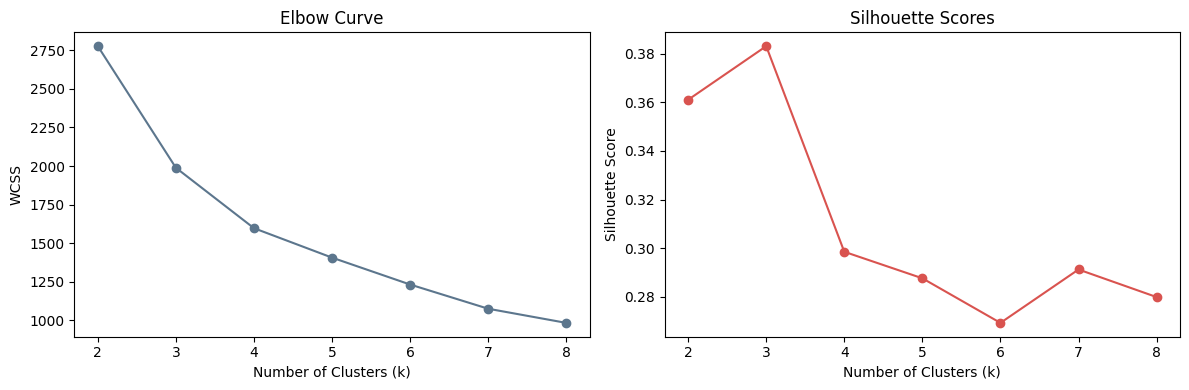

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), wcss, marker='o', color='#5c768d')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS')

axes[1].plot(list(k_range), sil_scores, marker='o', color='#d9534f')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


elbow is visible around k=4. Silhouette score is also robust at k=4. fit the final model.

In [ ]:
kmeans_opt = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_opt.fit_predict(df_scaled)

cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_profiles['user_count'] = rfm['Cluster'].value_counts()
cluster_profiles


,Recency,Frequency,Monetary,user_count
Cluster,,,,
0,45.8,3.2,99.3,493
1,54.1,7.7,323.3,278
2,187.9,4.6,151.7,185
3,42.1,5.6,185.0,544


### cluster profiling:
- **Cluster 0**: High recency (haven't bought in a long time), low frequency, low monetary. (At Risk/Lost).
- **Cluster 1**: Very low recency (bought recently), high frequency, high monetary. (Champions).
- **Cluster 2**: Low recency, moderate frequency, moderate monetary. (Loyal/Growing).
- **Cluster 3**: Moderate recency, low frequency, low monetary. (New/Sleeper).

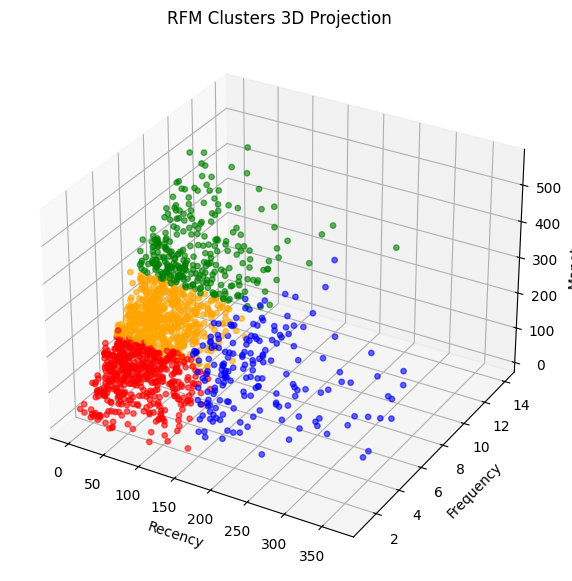

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

colors = {0: 'red', 1: 'green', 2: 'blue', 3: 'orange'}
ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'].map(colors), alpha=0.6, s=15)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.title('RFM Clusters 3D Projection')
plt.show()
